# pyPESTO Basics

This notebook provides a comprehensive introduction to parameter estimation with pyPESTO. You will learn how to:

1. Load a PEtab problem
2. Choose an optimizer
3. Make local optimization global via multistart
4. Run optimization
5. Save and load optimization results
6. Visualize results:
   - Model fit
   - Convergence (waterfall plot)
   - Parameter identifiability (parameter plots and correlations)

<img src="https://github.com/ICB-DCM/pyPESTO/raw/main/doc/logo/logo_wordmark.png" width="40%" alt="pyPESTO logo"/>

In [42]:
# Imports
import logging
import tempfile

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

import pypesto
import pypesto.optimize as optimize
import pypesto.petab
import pypesto.store as store
import pypesto.visualize as visualize

import petab
from matplotlib.pyplot import axes
from pypesto.visualize.model_fit import visualize_optimized_model_fit

# Set plot resolution
mpl.rcParams["figure.dpi"] = 100
mpl.rcParams["font.size"] = 18
# Set random seed for reproducibility
np.random.seed(1912)

## 1. Load the PEtab Problem

### What is PEtab?

[PEtab](https://github.com/PEtab-dev/PEtab) is a data format for specifying parameter estimation problems in systems biology. A PEtab problem consists of:

- An [SBML](https://sbml.org) file defining the model topology
- A set of `.tsv` files defining:
  - Experimental conditions
  - Observables
  - Measurements
  - Parameters (with optimization bounds, scale, priors, etc.)
- A `.yaml` file that links all these components together

The `pypesto.Objective` from a PEtab problem corresponds to the negative log-likelihood/negative log-posterior distribution of the parameters.

For this tutorial, we'll use a simple conversion reaction model.

In [3]:
# Path to the PEtab YAML configuration file
petab_yaml = "./petab_problem/problem.yaml"

# Create a PEtab importer from the YAML file
# The importer handles the translation of the PEtab problem into pyPESTO format
importer = pypesto.petab.PetabImporter.from_yaml(petab_yaml)

# Create the pyPESTO problem
# This includes the objective function, parameter bounds, and fixed parameters
problem = importer.create_problem(verbose=False)

print(f"Number of estimated parameters: {problem.dim}")
print(f"Parameter names: {problem.x_names}")

Visualization table not available. Skipping.
2026-03-11 10:42:05.797 - amici.sim.sundials.petab.v1._parameter_mapping - DEBUG - PEtab mapping: ({}, {'A0': 1.0, 'B0': 0.0, 'k_ab': 'k_ab', 'k_ba': 'k_ba'}, {}, {'A0': 'lin', 'B0': 'lin', 'k_ab': 'lin', 'k_ba': 'lin'})
2026-03-11 10:42:05.798 - amici.sim.sundials.petab.v1._parameter_mapping - DEBUG - Fixed parameters pre-equilibration: {}
2026-03-11 10:42:05.800 - amici.sim.sundials.petab.v1._parameter_mapping - DEBUG - Fixed parameters simulation: {'A0': 1.0, 'B0': 0.0}
2026-03-11 10:42:05.802 - amici.sim.sundials.petab.v1._parameter_mapping - DEBUG - Variable parameters pre-equilibration: {}
2026-03-11 10:42:05.803 - amici.sim.sundials.petab.v1._parameter_mapping - DEBUG - Variable parameters simulation: {'k_ab': 'k_ab', 'k_ba': 'k_ba'}
2026-03-11 10:42:05.804 - amici.sim.sundials.petab.v1._parameter_mapping - DEBUG - Merged: {'k_ab': 'k_ab', 'k_ba': 'k_ba'}


Number of estimated parameters: 2
Parameter names: ['k_ab', 'k_ba']


The problem object now contains:
- `problem.objective`: The objective function (negative log-likelihood)
- `problem.lb` and `problem.ub`: Lower and upper parameter bounds
- `problem.x_names`: Parameter names
- Information about fixed parameters

In [4]:
print("Objective function:", problem.objective)
print("Parameter names:", problem.x_names)
print("Parameter bounds:", problem.lb, problem.ub)

Objective function: <pypesto.objective.amici.amici.AmiciObjective object at 0x11a559590>
Parameter names: ['k_ab', 'k_ba']
Parameter bounds: [0 0] [10 10]


## 2. Choose the Optimizer

pyPESTO provides a unified interface to various optimization algorithms. The choice of optimizer can significantly impact the quality and speed of parameter estimation. pyPESTO supports a multitude of Optimozers, global and local, gradient-based and gradient-free.

In [5]:
attributes = []
for attr in dir(pypesto.optimize):
    obj = getattr(pypesto.optimize, attr)
    if (isinstance(obj, type) and issubclass(obj, optimize.Optimizer) and not obj is optimize.Optimizer):
        print(attr)


CmaOptimizer
DlibOptimizer
FidesOptimizer
IpoptOptimizer
NLoptOptimizer
PyswarmOptimizer
PyswarmsOptimizer
ScipyDifferentialEvolutionOptimizer
ScipyOptimizer



For ODE models with gradients provided by AMICI, **gradient-based optimizers** are typically most efficient. We'll use `FidesOptimizer` in this tutorial.

In [6]:
# Create the optimizer
optimizer = optimize.FidesOptimizer()

print(f"Selected optimizer: {optimizer}")

Selected optimizer: <FidesOptimizer  hessian_update=default verbose=20 options={}>


### Alternative: Scipy L-BFGS-B Optimizer

For comparison, here's how you would use the commonly-used L-BFGS-B optimizer:

In [7]:
# Alternative optimizer: L-BFGS-B
optimizer_lbfgsb = optimize.ScipyOptimizer(method="L-BFGS-B")
print(f"Alternative optimizer: {optimizer_lbfgsb}")

Alternative optimizer: <ScipyOptimizer method=L-BFGS-B options={'maxfun': 1000}>


## 3. Make Local Optimization Global via Multistart

Most optimization problems in systems biology have **multiple local minima**. A single optimization run from one starting point may converge to a local (rather than global) minimum.

In [8]:
result = optimize.minimize(
    problem=problem,
    optimizer=optimizer,
    n_starts=1,
)

  0%|          | 0/1 [00:00<?, ?it/s]2026-03-11 10:42:06 fides(INFO)  iter|    fval   |   fdiff  | tr ratio |tr radius|  ||g||  | ||step||| step|acc
2026-03-11 10:42:06 fides(INFO)     0| +4.03E+02 |    NaN   |    NaN   | 1.0E+00 | 9.4E+02 |   NaN   | NaN |1
2026-03-11 10:42:06 fides(INFO)     1| -6.44E+00 | -4.1E+02 | +1.7E-01 | 1.0E+00 | 9.4E+02 | 3.1E+00 |  2d |1
2026-03-11 10:42:06 fides(INFO)     2| -1.26E+01 | -6.2E+00 | +1.0E+00 | 2.5E-01 | 3.6E+01 | 3.3E-01 |  2d |1
2026-03-11 10:42:07 fides(INFO)     3| -1.26E+01 | -3.5E-02 | +1.0E+00 | 2.5E-01 | 2.5E+00 | 2.8E-02 |  2d |1
2026-03-11 10:42:07 fides(INFO)     4| -1.26E+01 | -1.6E-06 | +1.0E+00 | 2.5E-01 | 1.6E-02 | 1.9E-04 |  2d |1
2026-03-11 10:42:07 fides(INFO) Stopping as gradient norm satisfies absolute convergence criteria: 7.24E-07 < 1.00E-06
100%|██████████| 1/1 [00:00<00:00,  8.19it/s]



### The Multistart Approach

**Multistart optimization** addresses this by:
1. Sampling multiple starting points from the parameter space
2. Running local optimization from each starting point
3. Comparing results to identify the global optimum

In [9]:
# Set the number of optimization starts
n_starts = 50  # For real applications, use 100+ starts
optimizer.verbose = logging.ERROR

print(f"Number of multistart optimizations: {n_starts}")

Number of multistart optimizations: 50


### Parallelization

Since multistart optimizations are independent, they can be **parallelized** to reduce computation time:

In [10]:
# Create a parallel engine to distribute optimization runs across CPU cores
engine = pypesto.engine.MultiProcessEngine()

Engine will use up to 8 processes (= CPU count).


## 4. Run Optimization

Now we have all components ready:
- Problem (objective function + bounds)
- Optimizer algorithm
- Number of multistarts
- Parallelization engine

Let's run the optimization!

In [11]:
%%time

# Run multistart optimization
result = optimize.minimize(
    problem=problem,
    optimizer=optimizer,
    n_starts=n_starts,
    engine=engine,
)

  0%|          | 0/50 [00:00<?, ?it/s]2026-03-11 10:42:22.851 - amici.sim.sundials.petab._v2 - DEBUG - Changing log_level from 10 to 20
2026-03-11 10:42:22.854 - amici.sim.sundials.petab._v2 - DEBUG - Changing log_level from 10 to 20
2026-03-11 10:42:22.856 - amici.sim.sundials.petab._v2 - DEBUG - Changing log_level from 10 to 20
2026-03-11 10:42:22.856 - amici.sim.sundials.petab._v2 - DEBUG - Changing log_level from 10 to 20
2026-03-11 10:42:22.950 - amici.sim.sundials.petab._v2 - DEBUG - Changing log_level from 10 to 20
2026-03-11 10:42:23.001 - amici.sim.sundials.petab._v2 - DEBUG - Changing log_level from 10 to 20
2026-03-11 10:42:23.021 - amici.sim.sundials.petab._v2 - DEBUG - Changing log_level from 10 to 20
2026-03-11 10:42:23.072 - amici.sim.sundials.petab._v2 - DEBUG - Changing log_level from 10 to 20
100%|██████████| 50/50 [00:15<00:00,  3.30it/s]


CPU times: user 345 ms, sys: 361 ms, total: 706 ms
Wall time: 17.5 s


### Inspect the Results

The `result` object contains all optimization information. Let's examine the summary:

In [12]:
# Display optimization summary
display(Markdown(result.summary()))

## Optimization Result 

* number of starts: 50 
* best value: -12.809215826664696, id=41
* worst value: -12.640712975145574, id=26
* number of non-finite values: 0

* execution time summary:
	* Mean execution time: 0.066s
	* Maximum execution time: 0.313s,	id=41
	* Minimum execution time: 0.032s,	id=28
* summary of optimizer messages:

  |   Count | Message                                  |
  |--------:|:-----------------------------------------|
  |      27 | Converged according to fval difference   |
  |      22 | Converged according to gradient norm     |
  |       1 | Trust Region Radius too small to proceed |

* best value found (approximately) 2 time(s)
* number of plateaus found: 2

A summary of the best run:

### Optimizer Result

* optimizer used: <FidesOptimizer  hessian_update=default verbose=40 options={}>
* message: Trust Region Radius too small to proceed 
* number of evaluations: 40
* time taken to optimize: 0.313s
* startpoint: [1.01189669 0.42973771]
* endpoint: [0.43259563 0.18232603]
* final objective value: -12.809215826664696
* final gradient value: [-0.00018053 -0.00017117]
* final hessian value: [[  811.84706721 -1778.96985156]
 [-1778.96985156  3992.70807044]]


The summary includes:
- Best and worst objective values found
- Mean execution time per start
- Distribution of optimizer exit messages
- Details of the best optimization run

In [23]:
# Access specific results
print("Best objective value:", result.optimize_result.fval[0])
print("Best parameters:", result.optimize_result.x[0])
print("\nOne specific result:")
display(result.optimize_result.list[0])

Best objective value: -12.809215826664696
Best parameters: [0.43259563 0.18232603]

One specific result:


{'id': '41',
 'x': array([0.43259563, 0.18232603]),
 'fval': -12.809215826664696,
 'grad': array([-0.00018053, -0.00017117]),
 'hess': array([[  811.84706721, -1778.96985156],
        [-1778.96985156,  3992.70807044]]),
 'res': None,
 'sres': None,
 'n_fval': 40,
 'n_grad': 40,
 'n_hess': 40,
 'n_res': 0,
 'n_sres': 0,
 'x0': array([1.01189669, 0.42973771]),
 'fval0': -12.635252351615891,
 'history': <pypesto.history.base.CountHistory at 0x11a58e7b0>,
 'exitflag': <ExitFlag.DELTA_TOO_SMALL: -5>,
 'time': 0.3126089572906494,
 'message': 'Trust Region Radius too small to proceed',
 'optimizer': '<FidesOptimizer  hessian_update=default verbose=40 options={}>',
 'free_indices': array([0, 1]),
 'inner_parameters': None,
 'spline_knots': None}

## 5. Save Optimization (and Load)

Optimization can take considerable time, especially for large models. pyPESTO allows you to **save results to HDF5 format** and reload them later for visualization and further analysis.

### Save Results

In [14]:
# Create a temporary file for demonstration
# In practice, use a permanent filename like "results/my_optimization.hdf5"
result_file = tempfile.NamedTemporaryFile(suffix=".hdf5", delete=False)
result_filename = result_file.name

# Save the result to HDF5 file
store.write_result(
    result=result,
    filename=result_filename,
    problem=True,      # Save problem information
    optimize=True,     # Save optimization results
    profile=False,     # We haven't done profiling yet
    sample=False,      # We haven't done sampling yet
)

print(f"Results saved to: {result_filename}")
result_file.close()

Results saved to: /var/folders/2f/bnywv1ns2_9g8wtzlf_74yzh0000gn/T/tmppnm3olfl.hdf5


### Load Results

You can reload the results in a new session without re-running the optimization:

In [15]:
# Load the result from file
result_loaded = store.read_result(result_filename)

print("Results loaded successfully!")
print(f"Best objective value: {result_loaded.optimize_result.fval[0]}")

Loading the profiling result failed. It is highly likely that no profiling result exists within /var/folders/2f/bnywv1ns2_9g8wtzlf_74yzh0000gn/T/tmppnm3olfl.hdf5.
Loading the sampling result failed. It is highly likely that no sampling result exists within /var/folders/2f/bnywv1ns2_9g8wtzlf_74yzh0000gn/T/tmppnm3olfl.hdf5.


Results loaded successfully!
Best objective value: -12.809215826664696


**Important note:** The objective function is not fully saved to HDF5. For visualization, the loaded results work perfectly. However, if you need to evaluate the objective function again, you should recreate the problem from the PEtab files:

In [16]:
# Best practice: Reload the problem from PEtab
result_loaded.problem = problem

print("Problem reassigned to loaded result.")

Problem reassigned to loaded result.


## 6. Visualize

Visualization is crucial for:
- Assessing the quality of the model fit
- Checking optimizer convergence
- Identifying parameter identifiability issues

### 6.1 Model Fit

The most important visualization: **Does the model fit the data well?**

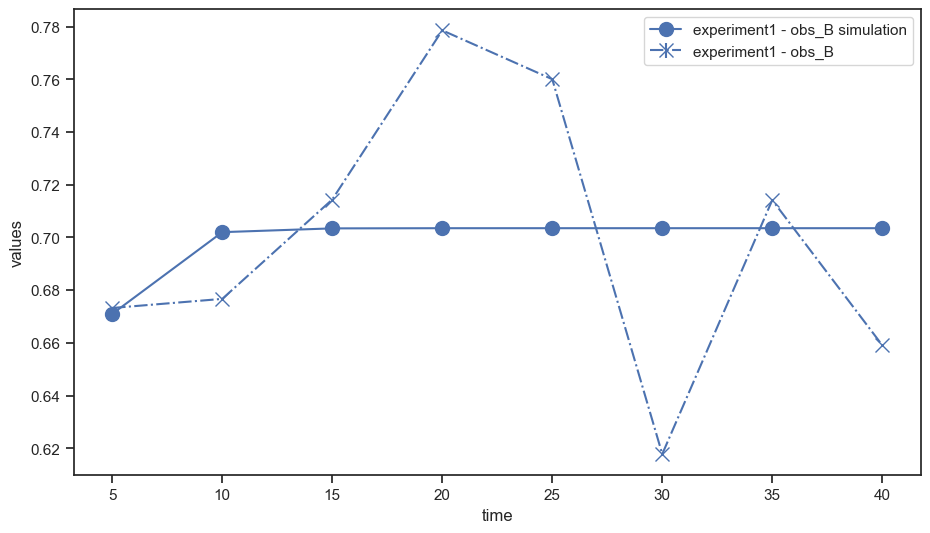

In [43]:
# Load the PEtab problem for visualization
petab_problem = petab.Problem.from_yaml(petab_yaml)

# Visualize the model fit with optimized parameters
ax = visualize_optimized_model_fit(
    petab_problem=petab_problem,
    result=result,
    pypesto_problem=problem
)
plt.gcf().set_size_inches(9, 5)
plt.show();

This plot shows:
- **Blue line**: Model simulation with optimized parameters
- **Points**: Experimental measurements
- **Error bars**: Measurement uncertainties

A good fit should have the model trajectory passing through or near the data points.

### 6.2 Convergence (Waterfall Plot)

The **waterfall plot** shows the final objective values from all optimization starts, sorted from best (lowest) to worst (highest).

**What to look for:**
- **Plateaus**: Indicate convergence to the same local minimum (good!)
- **Many different values**: Suggest multiple local minima or poor convergence

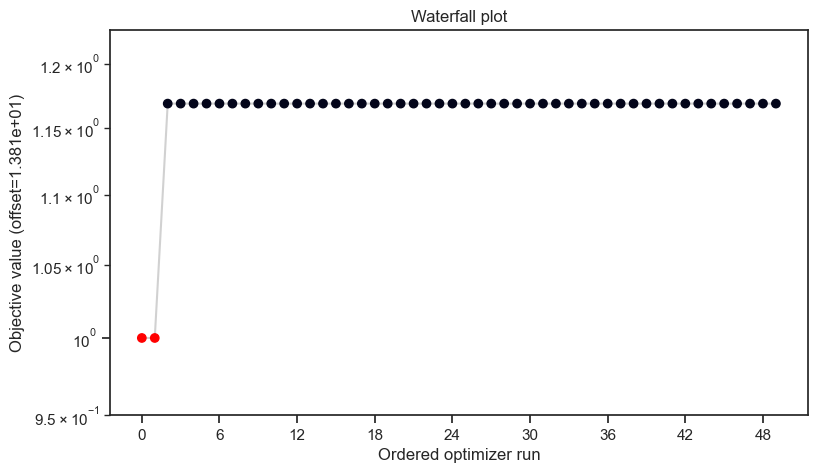

In [29]:
# Create waterfall plot
visualize.waterfall(
    result,
    size=(9,5)
);

**Interpretation:**
- Starts with similar colors converged to similar objective values
- The leftmost points represent the best optimization runs
- A clear plateau at the bottom indicates reliable convergence to the optimum

### 6.3 First Look at Identifiability

Parameter identifiability refers to whether parameters can be uniquely determined from the data. We can get initial insights through parameter plots.

#### Parameter Plot

This plot shows the parameter values from all optimization starts within their bounds.

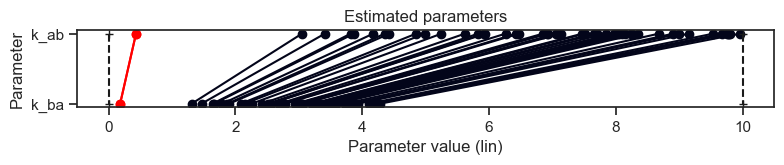

In [34]:
# Plot parameters from all starts
visualize.parameters(
    result,
    size=(9,1)
);

**What to look for:**
- **Clustering**: Best runs (darker colors) should cluster around similar values
- **Hitting bounds**: Parameters consistently at bounds may indicate poor model design
- **Wide spread**: Suggests the parameter may not be well-constrained by data (non-identifiable)

#### Parameter Correlation Plot

Some parameters may be **correlated** (changing one affects another). This can cause identifiability issues.

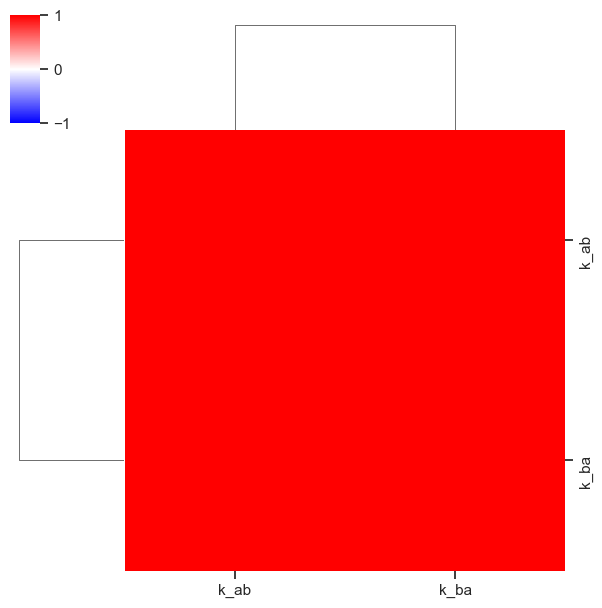

In [46]:
# Plot parameter correlations
visualize.parameters_correlation_matrix(result)
plt.gcf().set_size_inches(6, 6)
plt.show();

**Interpretation:**
- **Diagonal**: Always shows perfect correlation (1.0) with itself
- **Off-diagonal values close to ±1**: Strong correlation/anti-correlation between parameter pairs
- **Values near 0**: Parameters are independent

Strong correlations may indicate:
- Parameters that cannot be independently determined from data
- Potential for model reparameterization
- Need for additional data or fixing some parameters

#### Parameter Scatter Plot

Examine pairwise relationships between specific parameters:

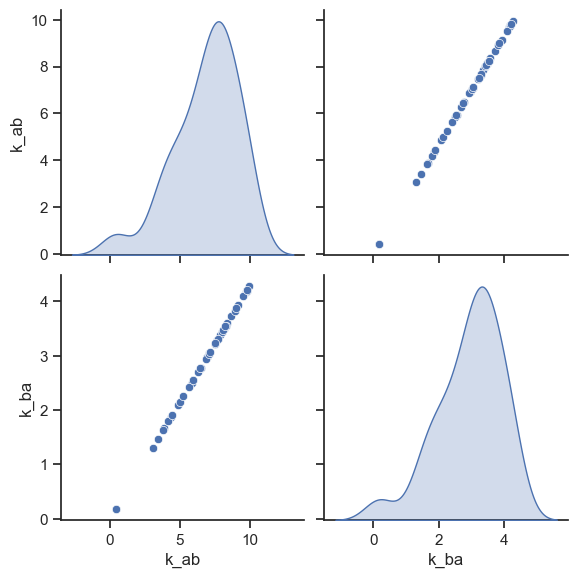

In [47]:
# Scatter plot of first two parameters
visualize.optimization_scatter(result, parameter_indices=[0, 1])
plt.gcf().set_size_inches(6, 6)
plt.show();

## Fixing Parameters

As we can see, there is a strong dependence of the two parameters. To validate that this is a mannifold in the 2D-parameter space, we can fix one of the parameters and re-run the optimization. While this is not rigorous approach to identifiability analysis, it can give us a quick insight into the structure of the parameter space. Fixing parameters is also very usefull, when using parameter values obtained from literature or previous experiments. To fix a parameter, we can use the problem:

In [51]:
print("Free parameters:", problem.x_free_indices)
print("Fixed parameters:", problem.x_fixed_indices)
problem.fix_parameters(parameter_indices=[0], parameter_vals=[2])
print("After Fixing Parameters:")
print("Free parameters:", problem.x_free_indices)
print("Fixed parameters:", problem.x_fixed_indices)

Free parameters: [0, 1]
Fixed parameters: []
After Fixing Parameters:
Free parameters: [1]
Fixed parameters: [0]


  0%|          | 0/50 [00:00<?, ?it/s]2026-03-11 11:13:34.918 - amici.sim.sundials.petab._v2 - DEBUG - Changing log_level from 10 to 20
2026-03-11 11:13:34.928 - amici.sim.sundials.petab._v2 - DEBUG - Changing log_level from 10 to 20
2026-03-11 11:13:34.933 - amici.sim.sundials.petab._v2 - DEBUG - Changing log_level from 10 to 20
2026-03-11 11:13:34.942 - amici.sim.sundials.petab._v2 - DEBUG - Changing log_level from 10 to 20
2026-03-11 11:13:34.955 - amici.sim.sundials.petab._v2 - DEBUG - Changing log_level from 10 to 20
2026-03-11 11:13:34.965 - amici.sim.sundials.petab._v2 - DEBUG - Changing log_level from 10 to 20
2026-03-11 11:13:34.971 - amici.sim.sundials.petab._v2 - DEBUG - Changing log_level from 10 to 20
2026-03-11 11:13:35.054 - amici.sim.sundials.petab._v2 - DEBUG - Changing log_level from 10 to 20
100%|██████████| 50/50 [00:13<00:00,  3.84it/s]


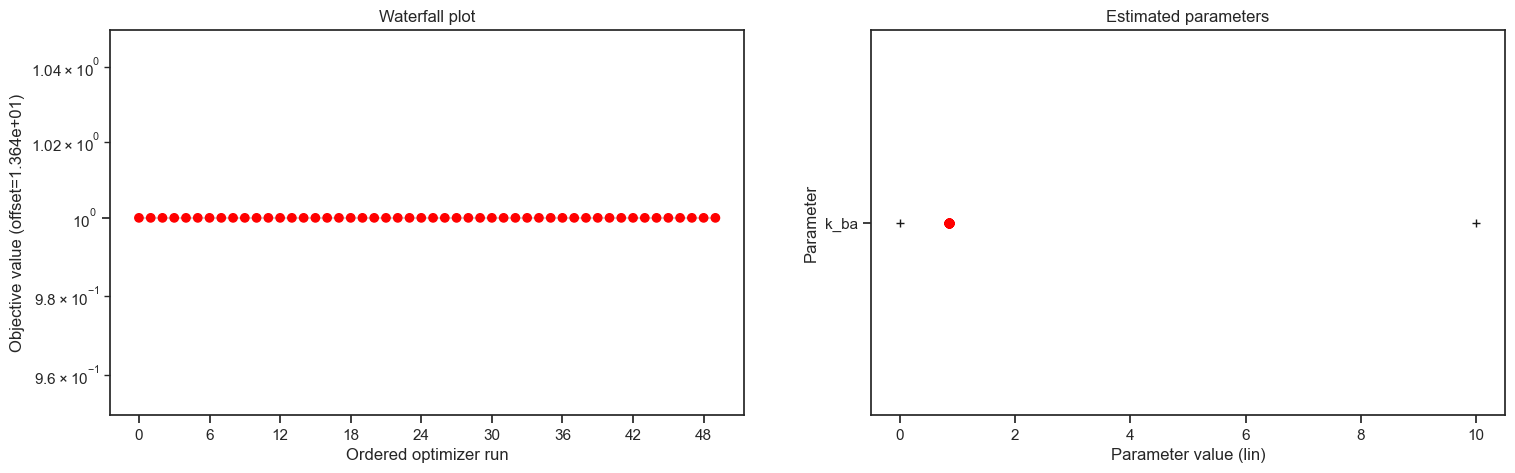

In [52]:
result = optimize.minimize(
    problem=problem,
    optimizer=optimizer,
    n_starts=n_starts,
    engine=engine,
)
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
visualize.waterfall(
    result,
    ax=axes[0]
)
visualize.parameters(
    result,
    ax=axes[1],
);

## Summary

In this tutorial, you learned the essential workflow for parameter estimation with pyPESTO:

1. **Load PEtab problem**: Import your model and data in standardized format
2. **Choose optimizer**: Select an appropriate optimization algorithm
3. **Multistart**: Use multiple starting points to find the global optimum
4. **Run optimization**: Execute the parameter estimation
5. **Save/Load**: Preserve results for later analysis
6. **Visualize**: Assess fit quality, convergence, and identifiability

### Next Steps

For more advanced analysis:
- **Profile Likelihoods**: Rigorous confidence intervals (see `getting_started.ipynb`)
- **MCMC Sampling**: Full posterior distributions (see `getting_started.ipynb`)

### Further Resources

- [pyPESTO Documentation](https://pypesto.readthedocs.io/)
- [pyPESTO GitHub](https://github.com/ICB-DCM/pyPESTO)
- [PEtab Documentation](https://petab.readthedocs.io/)
- [Example Notebooks](https://github.com/ICB-DCM/pyPESTO/tree/main/doc/example)